# FSL-AKE-IoD — Performance Verification

Hash operations are counted by **instrumenting** $h(\cdot)$ during real runs, not by hand. Bits use the paper's field
sizes (ID/nonce 160, hash 256, timestamp 32). Milliseconds use the paper's Table 6/7 averages
($T_h$ = 0.055 ms server, 0.309 ms Raspberry Pi 3). Real SHA-256 timings are measured on this machine.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "proposed", "code"))
import pandas as pd
pd.set_option("display.max_colwidth", 200)
from common import Clock, AuthError, h, xor, size_bits, reset_hash_counter, hashes
import cost, fslake as F

## 1. Hash operations per entity (instrumented)

In [2]:
rows = [cost.count_bakmm(), cost.count_bakmm("on_send"), cost.count_fsl_v1(), cost.count_fsl(),
        cost.count_fsl(F.without(M6_two_message=False), "FSL v2 + MSG3 (M6 off)"),
        cost.count_fsl(F.without(retry_pseudonyms=3), "FSL v2 + retry pseudonyms w=3")]
pd.DataFrame([{k: r[k] for k in ("scheme", "de", "es", "msgs", "bits", "per_msg")} for r in rows])

,scheme,de,es,msgs,bits,per_msg
0,BAKMM-IoD,8,8,3,1792,"[704, 800, 288]"
1,BAKMM-IoD,8,8,3,1792,"[704, 800, 288]"
2,FSL-AKE-IoD v1 (draft),5,7,2,1056,"[608, 448]"
3,FSL-AKE-IoD v2,5,7,2,1056,"[608, 448]"
4,FSL v2 + MSG3 (M6 off),6,8,3,1344,"[608, 448, 288]"
5,FSL v2 + retry pseudonyms w=3,5,10,2,1056,"[608, 448]"


In [3]:
print('BAKMM per step:', cost.count_bakmm()['de_steps'], cost.count_bakmm()['es_steps']); print(cost.count_bakmm_km())

BAKMM per step: {'AKDDE1': 3, 'AKDDE3': 5} {'AKDDE2': 7, 'AKDDE4': 1}
{'scheme': 'BAKMM-IoD ES-CS (corrected)', 'es': 8, 'cs': 8, 'bits': 1792, 'msgs': 3}


**Output explanation.** BAKMM-IoD: drone 3 (AKDDE1) + 5 (AKDDE3) = **8**, ES 7 (AKDDE2) + 1 (AKDDE4) = **8**. This
matches the paper's Table 8 ($8T_h$/$8T_h$), although the paper does not say how it counted.
FSL-AKE-IoD v1 and v2: **5/7**. The review fixes add no hash. The optional 3-message variant costs 6/8, and retry
pseudonyms cost the ES $w$ extra hashes.

## 2. Communication cost

In [4]:
b, f = cost.count_bakmm(), cost.count_fsl()
print(f"BAKMM-IoD : {' + '.join(map(str, b['per_msg']))} = {b['bits']} bits in {b['msgs']} messages "
      f"(M5 counted as 256 bits like the paper; {b['bits_actual']} if M5 is 160 bits)")
print(f"FSL-AKE-IoD: {' + '.join(map(str, f['per_msg']))} = {f['bits']} bits in {f['msgs']} messages")
print(f"saving: {100 * (1 - f['bits'] / b['bits']):.1f} %")

BAKMM-IoD : 704 + 800 + 288 = 1792 bits in 3 messages (M5 counted as 256 bits like the paper; 1696 if M5 is 160 bits)
FSL-AKE-IoD: 608 + 448 = 1056 bits in 2 messages
saving: 41.1 %


**Output explanation.** 1792 → 1056 bits (−41.1 %) and 3 → 2 messages, as the draft claims. The paper's §7.2 total prints 1782, but its own terms sum to 1792.

## 3. Real timings on this machine

In [5]:
t = cost.sha256_timing(100_000)
print(f"h() (5-part SHA-256): mean {t['h_mean_ms']*1e3:.3f} us, std {t['h_std_ms']*1e3:.3f} us, median {t['h_median_ms']*1e3:.3f} us  (n={t['runs']})")
print(f"raw hashlib, 64 B   : mean {t['raw_mean_ms']*1e3:.3f} us, std {t['raw_std_ms']*1e3:.3f} us, median {t['raw_median_ms']*1e3:.3f} us")
s = cost.session_timing(5000)
pd.DataFrame(s).T.map(lambda v: f"{v*1e3:.1f} us")

h() (5-part SHA-256): mean 7.121 us, std 32.329 us, median 5.100 us  (n=100000)
raw hashlib, 64 B   : mean 2.072 us, std 15.218 us, median 1.500 us


,mean_ms,std_ms,median_ms
BAKMM-IoD,135.0 us,165.5 us,108.0 us
FSL-AKE-IoD v2,100.9 us,95.6 us,72.3 us


**Output explanation.** A SHA-256 call costs a few microseconds in CPython. The large standard deviation comes from
OS scheduling outliers (the median is the robust figure). A full FSL-AKE-IoD session runs faster than a BAKMM-IoD
session on this machine, as the hash counts predict. These are PC numbers in Python; they are **not** comparable with
the paper's MIRACL/Raspberry Pi figures, which is why the comparison below uses the paper's $T_h$.

## 4. Comparison with the paper's Table 8/9 schemes

In [6]:
rows = cost.comparison_rows()
pd.DataFrame(rows)[["scheme", "drone_f", "drone_ms", "server_f", "server_ms", "msgs", "bits"]]

,scheme,drone_f,drone_ms,server_f,server_ms,msgs,bits
0,Ali et al.,18Th+Tfe+Tsenc,7.868,7Th+3Tsenc/Tsdec,0.394,3,3424
1,Cho et al.,2Tecsigv+Tsdec+10001Th,3100.125,2Tecsigg+Tsenc+10001Th,551.516,3,3968
2,Rodrigues et al.,9Th+6Tecm,16.509,9Th+2Tecm,1.843,4,3456
3,Ever,9Th+2Tbp+2Tmtp+3Tecm,74.583,6Th+3Tbp+2Tmtp+3Tecm,16.728,6,5344
4,Bera et al.,9Th+2Tsenc/Tsdec+2Tecm+Teca,7.405,9Th+2Tsenc/Tsdec+2Tecm+Teca,1.851,3,2368
5,Mishra et al.,9Th,2.780,7Th,0.390,3,1792
6,Algarni and Jan,Tfe+14Th,6.614,6Th,0.330,4,2784
7,BAKMM-IoD,8Th,2.472,8Th,0.440,3,1792
8,FSL-AKE-IoD (v2),5Th,1.545,7Th,0.385,2,1056


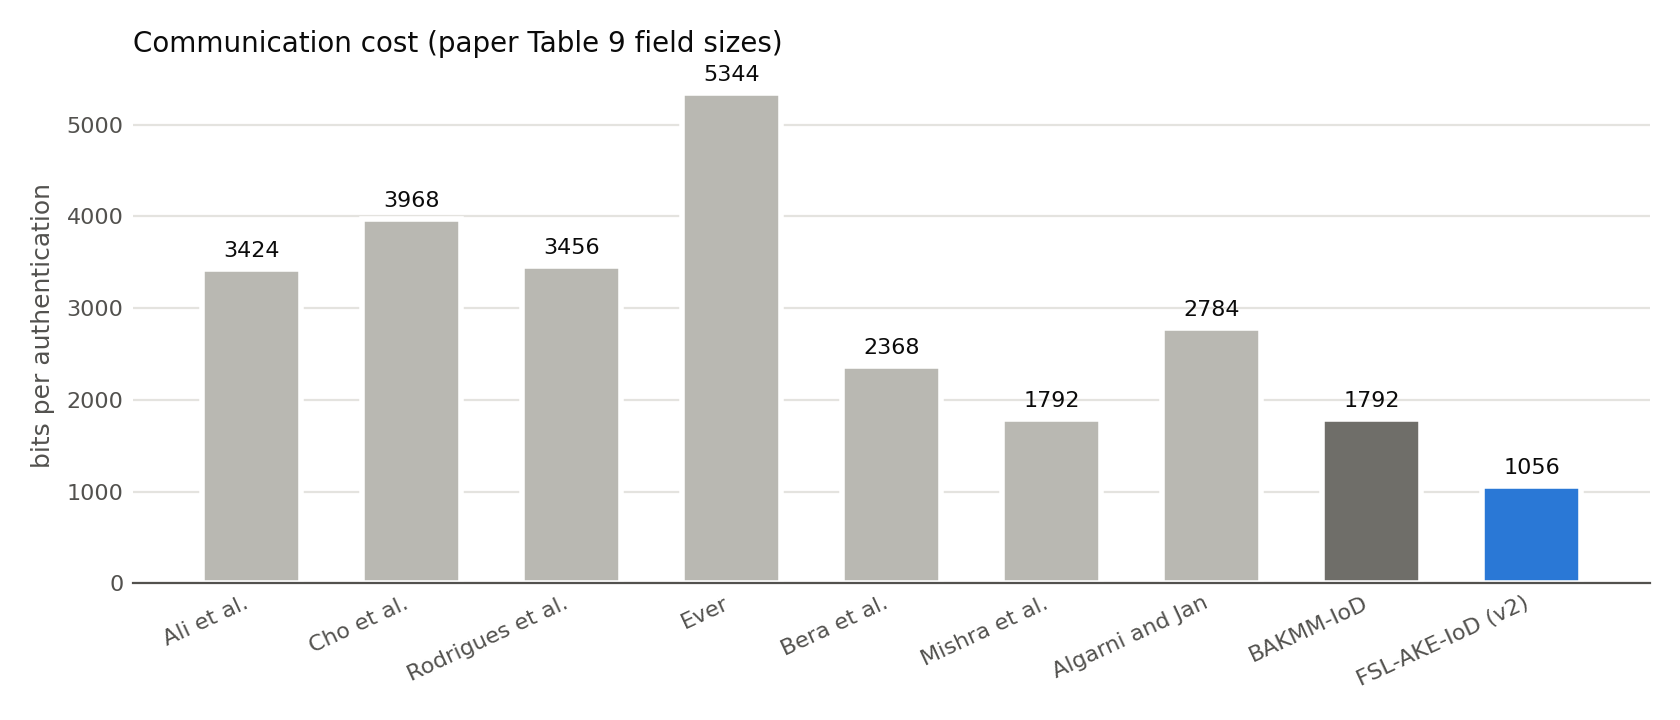

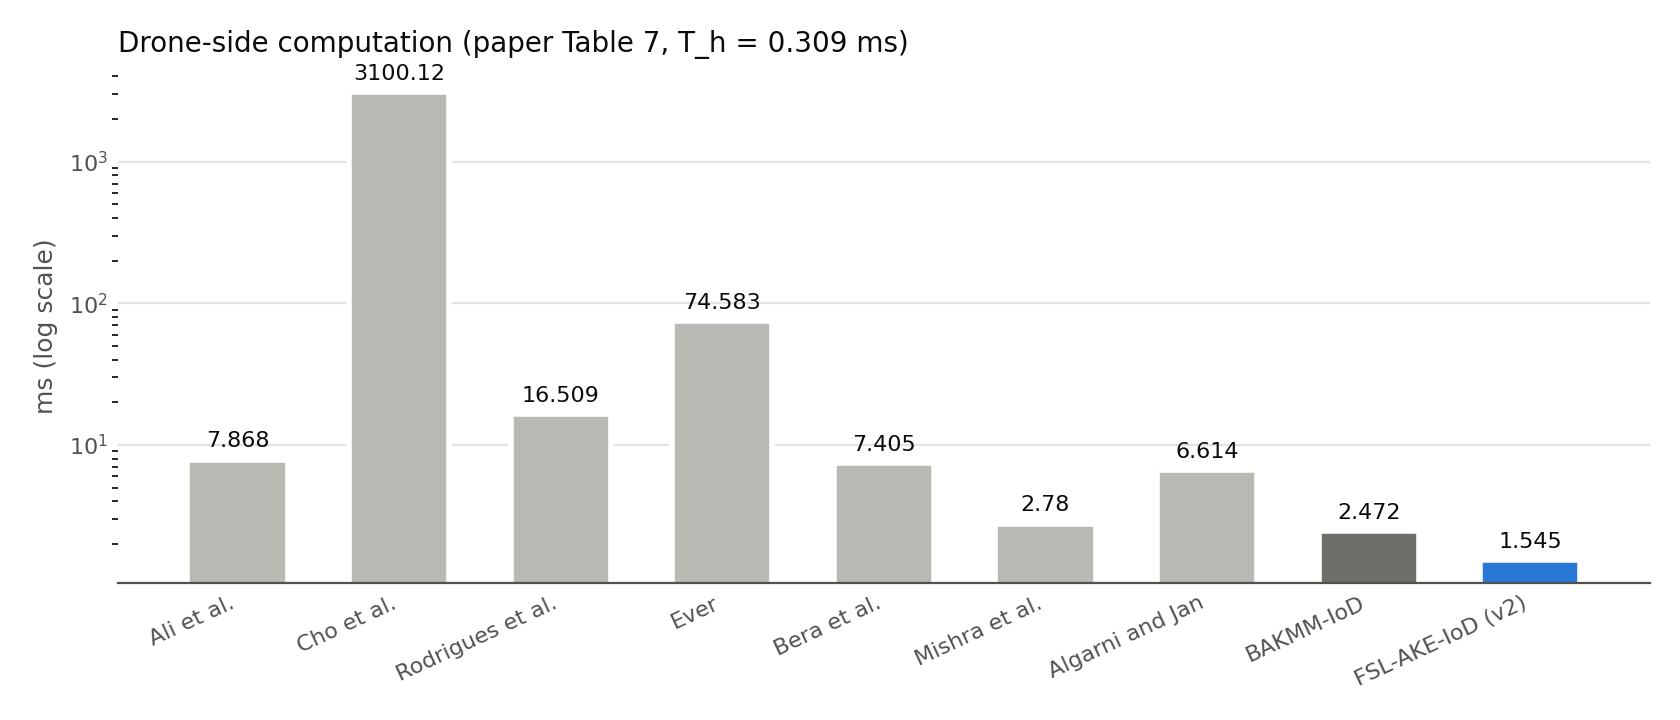

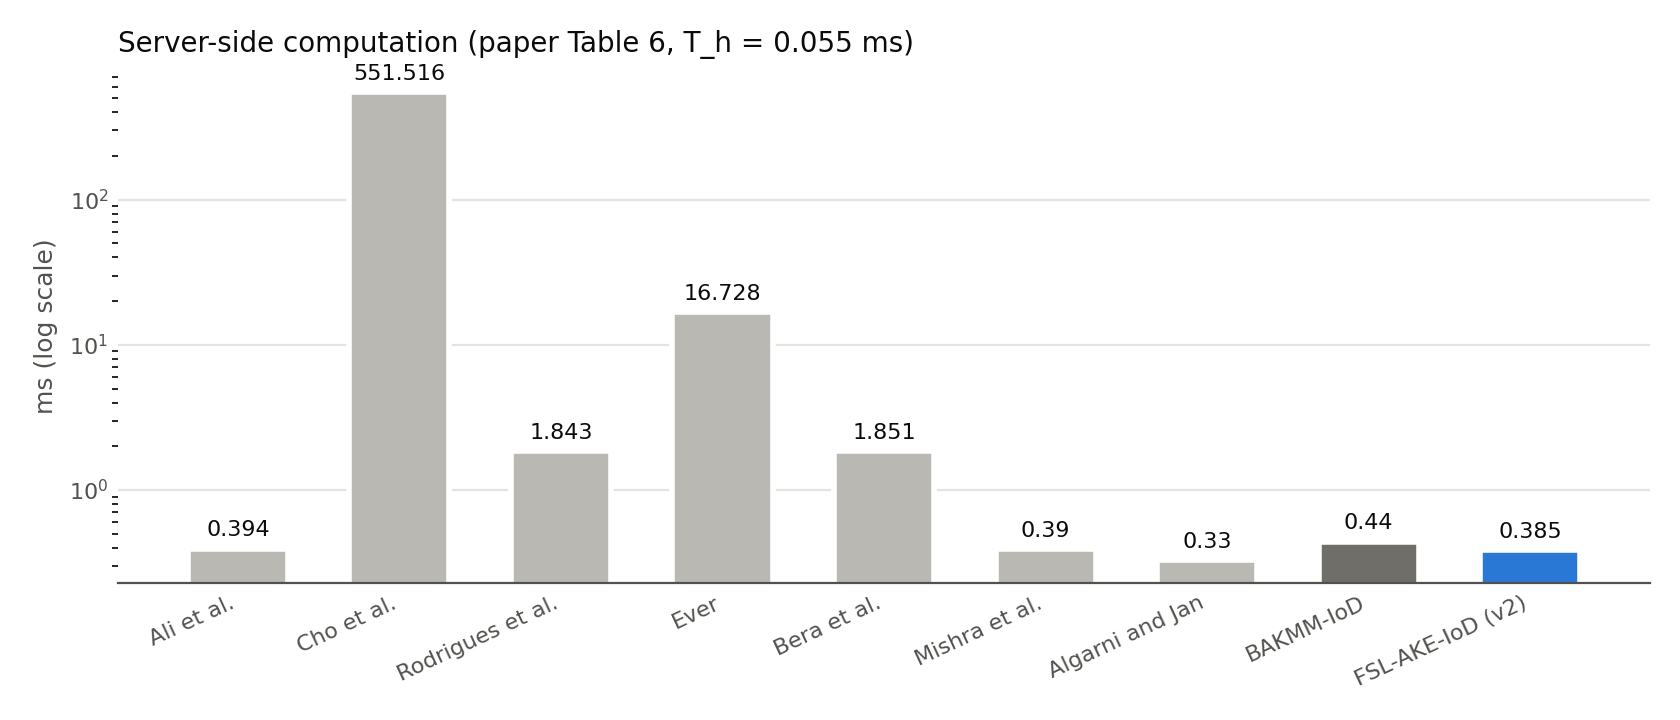

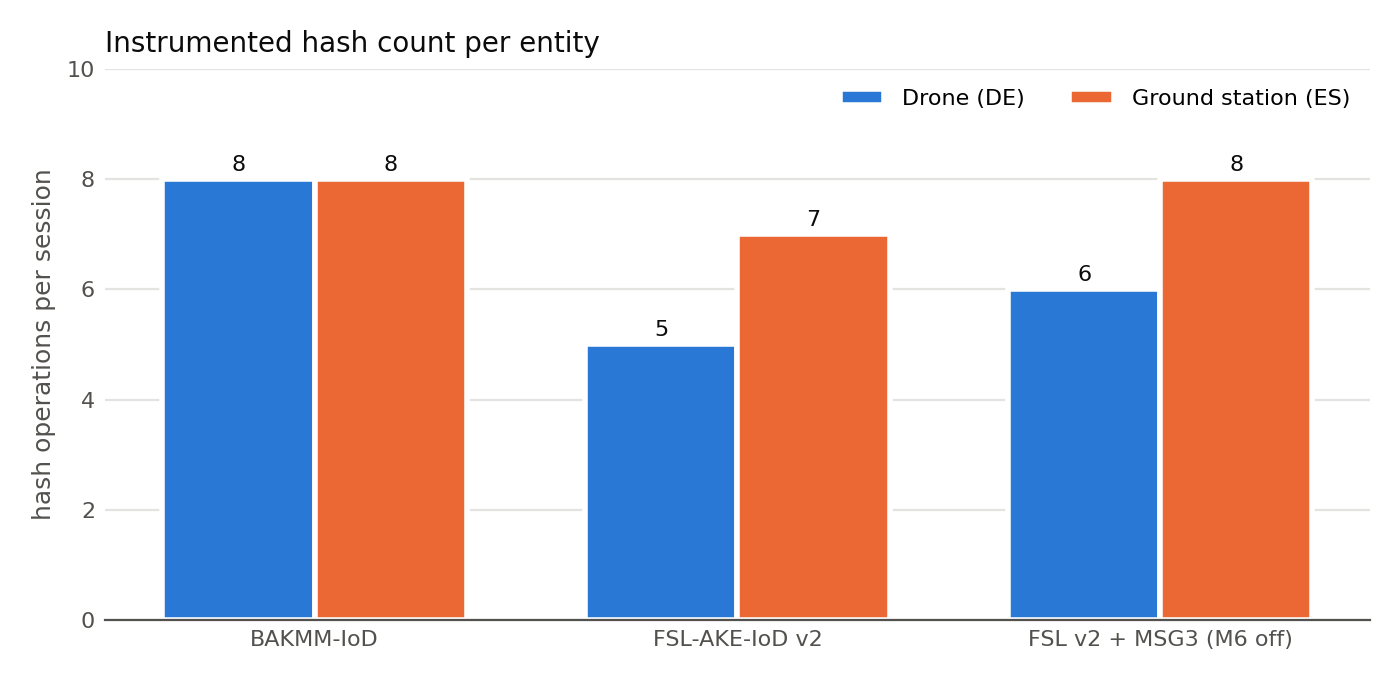

In [7]:
import charts
paths = charts.main()
from IPython.display import Image, display
for p in paths: display(Image(filename=p, width=760))

## 5. Is FSL-AKE-IoD strictly cheaper on both computation and communication?

In [8]:
me, ties = cost.strictly_cheaper(rows)
for metric, lst in ties.items():
    print(f"{metric:10s}: FSL = {me[metric]}; schemes at least as cheap: {lst if lst else 'none'}")

drone_ms  : FSL = 1.545; schemes at least as cheap: none
server_ms : FSL = 0.385; schemes at least as cheap: [('Algarni and Jan', 0.33)]
bits      : FSL = 1056; schemes at least as cheap: none
msgs      : FSL = 2; schemes at least as cheap: none


**Output explanation — answer: no, not on the server.**
* Drone: $5T_h$ = 1.545 ms, the lowest of all nine schemes.
* Communication: 1056 bits in 2 messages, the lowest bits and fewest messages.
* **Server: $7T_h$ = 0.385 ms is higher than Algarni & Jan ($6T_h$ = 0.33 ms)** and equal to Mishra et al. ($7T_h$,
  printed as 0.39 ms). It is lower only than BAKMM-IoD and the others. The draft's abstract says "cheaper … in both
  computation and communication"; that holds against BAKMM-IoD, not against every compared scheme.
* Counting convention: Table 8's figures for other schemes come from their own papers and may count only
  sender-side hashes. Our 5/7 includes every verification hash, so the comparison is, if anything, conservative for
  FSL-AKE-IoD.

## 6. Storage and collision bound

In [9]:
print("drone storage: BAKMM {TID, RID, TC, MS} =", 20 + 32 + 32 + 32, "bytes;  FSL {TID, K} =", 20 + 32, "bytes")
print("ES storage per drone (FSL v2): anchor + <= 4 candidates, each (TID 20 + C 32) bytes -> 52..260 bytes; steady state 104 bytes")
print(cost.tid_collision_bound())

drone storage: BAKMM {TID, RID, TC, MS} = 116 bytes;  FSL {TID, K} = 52 bytes
ES storage per drone (FSL v2): anchor + <= 4 candidates, each (TID 20 + C 32) bytes -> 52..260 bytes; steady state 104 bytes
{'n_bits': 160, 'pseudonyms': 2000000000000, 'bound': 1.3684555315672041e-24, 'log10': -23.86376931057301}


**Output explanation.** From the paper's field sizes we get 116 bytes for the BAKMM-IoD drone (TID 20 + RID 32 + TC 32
+ MS 32; RID and TC are hash outputs, and MS is taken as 256 bits). The draft's "about 136 bytes" cannot be reproduced
from the stated sizes and should be corrected or explained. In the steady state the FSL ES holds two records per drone,
matching the draft's "2 × 52 bytes"; the candidate list can briefly grow to five records.